Bismillah,

In this code, I am going to dig into ALiRAS and VGGish predictions for 7000 training and testing data, these 7000 data is the first 7000 of LA 2019 training as well as the first 7000 of 2021 evaluation sets.

# Round 2
 we made sure that the same dataset (training and testing) are used for ALiRAS, VGGish and XLSR, and HuBERT

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras import Input
from tensorflow.keras.layers import concatenate, Permute, Reshape
import os

In [ ]:
import math
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
from imblearn.over_sampling import SMOTE


In [ ]:
#from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM,TimeDistributed
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization
from keras.layers import MaxPooling2D
from keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import StratifiedKFold
import numpy as np
import sklearn.metrics as metrics

In [ ]:
import pandas as pd
import math
import numpy as np
#from numpy.lib.function_base import average
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import models, layers
import tensorflow as tf
from matplotlib.pyplot import specgram
import glob

In [ ]:
from sklearn.metrics import confusion_matrix
import IPython.display as ipd  # To play sound in the notebook
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import sys
import warnings
# ignore warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
import json

from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

import pickle
import joblib
from tensorflow.keras import models, layers
import tensorflow as tf

In [ ]:
import pandas as pd

In [ ]:
df_main = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/hubert_predictions/DF_train_probs_aliras_vggish_xlsr_hubert_ensemble_7000version_matched.csv')

In [ ]:
df_main_test = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/hubert_predictions/DF_test_probs_aliras_vggish_xlsr_hubert_ensemble_7000version_matched.csv')

In [ ]:
df_main

,FileName,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_hubert
0,LA_T_1000137,1.000000,0.988396,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.686863,0.711449,0.000627,0.536406,1.000000,0.907281,0.581605,0.860922
1,LA_T_1000406,0.000488,0.000004,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,0.0,0.405460,0.132607,0.917173,0.475731,0.000289,0.095377,0.428158,0.143061
2,LA_T_1000648,0.999995,0.992399,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.557978,0.357509,0.375939,0.494682,1.000000,0.898936,0.544454,0.848401
3,LA_T_1000824,0.998608,0.092008,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.477041,0.128973,0.589496,0.477918,0.793709,0.730551,0.439327,0.842401
4,LA_T_1001074,1.000000,0.981404,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.708737,0.271826,0.657384,0.506093,0.999986,0.901207,0.553624,0.851828
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6992,LA_T_3469583,0.999991,0.966615,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.664643,0.263867,0.089851,0.524127,1.000000,0.904825,0.568376,0.857232
6993,LA_T_3469591,0.999999,0.993235,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.402866,0.092832,0.929591,0.475402,0.957116,0.860773,0.527185,0.842620
6994,LA_T_3469711,1.000000,0.600456,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.073397,0.401341,0.962500,0.465682,0.999918,0.893071,0.479160,0.839705
6995,LA_T_3470036,1.000000,0.003307,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.784636,0.629113,0.943449,0.534822,1.000000,0.906964,0.481671,0.860447


In [ ]:
df_main_train = df_main

In [ ]:
train_wavlm = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/wavlm_predictions/train_predictions_wavlm_mlp_7000_df.csv')

In [ ]:
test_wavlm = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/wavlm_predictions/test_predictions_wavlm_mlp_7000_df.csv')

In [ ]:
train_wavlm

,audio_filenames,prob_spoof
0,LA_T_1000137,1.000000e+00
1,LA_T_1000406,1.755506e-08
2,LA_T_1000648,1.000000e+00
3,LA_T_1000824,1.000000e+00
4,LA_T_1001074,1.000000e+00
...,...,...
6994,LA_T_3469583,1.000000e+00
6995,LA_T_3469591,1.000000e+00
6996,LA_T_3469711,1.000000e+00
6997,LA_T_3470036,1.000000e+00


In [ ]:

train_wavlm = train_wavlm.rename(columns={'prob_spoof': 'prob_spoof_wavlm'})
test_wavlm = test_wavlm.rename(columns={'prob_spoof': 'prob_spoof_wavlm'})

In [ ]:
test_wavlm

,audio_filenames,prob_spoof_wavlm
0,DF_E_2000011,1.0
1,DF_E_2000013,1.0
2,DF_E_2000024,1.0
3,DF_E_2000026,1.0
4,DF_E_2000027,1.0
...,...,...
6995,DF_E_2034401,1.0
6996,DF_E_2034402,1.0
6997,DF_E_2034405,1.0
6998,DF_E_2034408,1.0


In [ ]:
train_wavlm = train_wavlm.rename(columns={'audio_filenames': 'FileName'})


In [ ]:
test_wavlm = test_wavlm.rename(columns={'audio_filenames': 'FileName'})


In [ ]:
concatenated_df_train = df_main_train

In [ ]:
concatenated_df_test = df_main_test

In [ ]:

merged_df_train = pd.merge(train_wavlm, concatenated_df_train, on='FileName', how='left')

# Optional: verify result
print(merged_df_train.head())
print(f"Shape of merged dataframe: {merged_df_train.shape}")


       FileName  prob_spoof_wavlm  prob_spoof_hubert_resnet18  \
0  LA_T_1000137      1.000000e+00                    1.000000   
1  LA_T_1000406      1.755506e-08                    0.000488   
2  LA_T_1000648      1.000000e+00                    0.999995   
3  LA_T_1000824      1.000000e+00                    0.998608   
4  LA_T_1001074      1.000000e+00                    1.000000   

   prob_spoof_from_XLSR_ResNet18  \
0                       0.988396   
1                       0.000004   
2                       0.992399   
3                       0.092008   
4                       0.981404   

                                                Path  Label  audio_quality  \
0  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...    1.0       0.686863   
1  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...    0.0       0.405460   
2  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...    1.0       0.557978   
3  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...    1.0       0.477041   
4 

In [ ]:
merged_df_train

,FileName,prob_spoof_wavlm,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_hubert
0,LA_T_1000137,1.000000e+00,1.000000,0.988396,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.686863,0.711449,0.000627,0.536406,1.000000,0.907281,0.581605,0.860922
1,LA_T_1000406,1.755506e-08,0.000488,0.000004,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,0.0,0.405460,0.132607,0.917173,0.475731,0.000289,0.095377,0.428158,0.143061
2,LA_T_1000648,1.000000e+00,0.999995,0.992399,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.557978,0.357509,0.375939,0.494682,1.000000,0.898936,0.544454,0.848401
3,LA_T_1000824,1.000000e+00,0.998608,0.092008,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.477041,0.128973,0.589496,0.477918,0.793709,0.730551,0.439327,0.842401
4,LA_T_1001074,1.000000e+00,1.000000,0.981404,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.708737,0.271826,0.657384,0.506093,0.999986,0.901207,0.553624,0.851828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6994,LA_T_3469583,1.000000e+00,0.999991,0.966615,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.664643,0.263867,0.089851,0.524127,1.000000,0.904825,0.568376,0.857232
6995,LA_T_3469591,1.000000e+00,0.999999,0.993235,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.402866,0.092832,0.929591,0.475402,0.957116,0.860773,0.527185,0.842620
6996,LA_T_3469711,1.000000e+00,1.000000,0.600456,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.073397,0.401341,0.962500,0.465682,0.999918,0.893071,0.479160,0.839705
6997,LA_T_3470036,1.000000e+00,1.000000,0.003307,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2019_LA...,1.0,0.784636,0.629113,0.943449,0.534822,1.000000,0.906964,0.481671,0.860447


In [ ]:
merged_df_train = merged_df_train.rename(columns={'prob_spoof_wavlm': 'prob_spoof_wavlm_mlp'})
#merged_df_test = merged_df_test.rename(columns={'prob_spoof_hubert': 'prob_spoof_hubert_resnet18'})

In [ ]:
nan_count = merged_df_train['Label'].isna().sum()
print(f"Number of NaN values in 'Label': {nan_count}")


Number of NaN values in 'Label': 2


In [ ]:


merged_df_train.dropna(subset=['Label'], inplace=True)

# Optional: verify result
nan_count_after = merged_df_train['Label'].isna().sum()
print(f"Number of NaN values in 'Label' after dropping: {nan_count_after}")
print(f"Shape of dataframe after dropping NaNs: {merged_df_train.shape}")

Number of NaN values in 'Label' after dropping: 0
Shape of dataframe after dropping NaNs: (6997, 14)


In [ ]:
merged_df_test = pd.merge(test_wavlm, concatenated_df_test, on='FileName', how='left')

# Optional: verify result
print(merged_df_test.head())
print(f"Shape of merged dataframe: {merged_df_test.shape}")


       FileName  prob_spoof_wavlm  prob_spoof_hubert_resnet18  \
0  DF_E_2000011               1.0                    1.000000   
1  DF_E_2000013               1.0                    0.999395   
2  DF_E_2000024               1.0                    1.000000   
3  DF_E_2000026               1.0                    1.000000   
4  DF_E_2000027               1.0                    1.000000   

   prob_spoof_from_XLSR_ResNet18  \
0                       0.931213   
1                       0.958799   
2                       0.003900   
3                       0.535835   
4                       0.007246   

                                                Path  Label  audio_quality  \
0  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...    1.0       0.509246   
1  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...    1.0       0.391012   
2  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...    1.0       0.775842   
3  /nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...    1.0       0.905625   
4 

In [ ]:
merged_df_test

,FileName,prob_spoof_wavlm,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_hubert
0,DF_E_2000011,1.0,1.000000,0.931213,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.509246,0.506505,0.002466,0.904300,0.562474,0.521502,1.000000,0.856451
1,DF_E_2000013,1.0,0.999395,0.958799,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.391012,0.181437,0.003677,0.901393,0.565281,0.521556,0.996353,0.856044
2,DF_E_2000024,1.0,1.000000,0.003900,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.775842,0.784149,0.000334,0.910243,0.496486,0.551218,0.999999,0.865365
3,DF_E_2000026,1.0,1.000000,0.535835,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.905625,0.511231,0.000951,0.910214,0.549548,0.551072,1.000000,0.865322
4,DF_E_2000027,1.0,1.000000,0.007246,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.655513,0.618699,0.579733,0.903117,0.470805,0.522311,0.998319,0.856693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,DF_E_2034401,1.0,0.999865,0.805376,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.664837,0.474970,0.143835,0.904294,0.549968,0.521589,0.999970,0.856382
6996,DF_E_2034402,1.0,1.000000,0.620533,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.924276,0.436578,0.003243,0.910336,0.558567,0.551682,1.000000,0.865505
6997,DF_E_2034405,1.0,0.998028,0.999959,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.516034,0.553612,0.847947,0.899790,0.549050,0.498949,1.000000,0.848304
6998,DF_E_2034408,1.0,0.999553,0.040554,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.480987,0.316607,0.844016,0.894681,0.436970,0.481016,0.998097,0.843992


In [ ]:
nan_count = merged_df_test['Label'].isna().sum()
print(f"Number of NaN values in 'Label': {nan_count}")


Number of NaN values in 'Label': 3


In [ ]:
merged_df_test = merged_df_test.rename(columns={'prob_spoof_wavlm': 'prob_spoof_wavlm_mlp'})

In [ ]:
merged_df_test

,FileName,prob_spoof_wavlm_mlp,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_hubert
0,DF_E_2000011,1.0,1.000000,0.931213,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.509246,0.506505,0.002466,0.904300,0.562474,0.521502,1.000000,0.856451
1,DF_E_2000013,1.0,0.999395,0.958799,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.391012,0.181437,0.003677,0.901393,0.565281,0.521556,0.996353,0.856044
2,DF_E_2000024,1.0,1.000000,0.003900,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.775842,0.784149,0.000334,0.910243,0.496486,0.551218,0.999999,0.865365
3,DF_E_2000026,1.0,1.000000,0.535835,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.905625,0.511231,0.000951,0.910214,0.549548,0.551072,1.000000,0.865322
4,DF_E_2000027,1.0,1.000000,0.007246,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.655513,0.618699,0.579733,0.903117,0.470805,0.522311,0.998319,0.856693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,DF_E_2034401,1.0,0.999865,0.805376,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.664837,0.474970,0.143835,0.904294,0.549968,0.521589,0.999970,0.856382
6996,DF_E_2034402,1.0,1.000000,0.620533,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.924276,0.436578,0.003243,0.910336,0.558567,0.551682,1.000000,0.865505
6997,DF_E_2034405,1.0,0.998028,0.999959,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.516034,0.553612,0.847947,0.899790,0.549050,0.498949,1.000000,0.848304
6998,DF_E_2034408,1.0,0.999553,0.040554,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.480987,0.316607,0.844016,0.894681,0.436970,0.481016,0.998097,0.843992


In [ ]:
# Step 1: Create a mapping from FileName to index in concatenated_df_train
#file_to_index_map = concatenated_df_train.reset_index().set_index('FileName').index.to_series()

# Step 2: Get FileName column from merged_df_train in order
#file_names_in_merged = merged_df_train['FileName']

# Step 3: Find corresponding indexes (may contain NaN if not present)
#matching_indexes = file_names_in_merged.map(lambda x: concatenated_df_train.index[concatenated_df_train['FileName'] == x].tolist())

# Step 4: Flatten the list and handle missing
#matching_indexes_flat = [idx[0] if idx else None for idx in matching_indexes]

# Print matching indexes
#print(matching_indexes_flat)


In [ ]:


# Filter out None (i.e., files not found in concatenated_df_train)
#valid_indexes = [idx for idx in matching_indexes_flat if idx is not None]

# Create corresponding X_train subset
#X_train_matched = X_train[valid_indexes]

# Print shape to confirm
#print(f"Shape of X_train_matched: {X_train_matched.shape}")


In [ ]:
merged_df_test.dropna(subset=['Label'], inplace=True)

# Optional: verify result
nan_count_after = merged_df_test['Label'].isna().sum()
print(f"Number of NaN values in 'Label' after dropping: {nan_count_after}")
print(f"Shape of dataframe after dropping NaNs: {merged_df_train.shape}")

Number of NaN values in 'Label' after dropping: 0
Shape of dataframe after dropping NaNs: (6997, 14)


In [ ]:
merged_df_test

,FileName,prob_spoof_wavlm_mlp,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_hubert
0,DF_E_2000011,1.0,1.000000,0.931213,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.509246,0.506505,0.002466,0.904300,0.562474,0.521502,1.000000,0.856451
1,DF_E_2000013,1.0,0.999395,0.958799,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.391012,0.181437,0.003677,0.901393,0.565281,0.521556,0.996353,0.856044
2,DF_E_2000024,1.0,1.000000,0.003900,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.775842,0.784149,0.000334,0.910243,0.496486,0.551218,0.999999,0.865365
3,DF_E_2000026,1.0,1.000000,0.535835,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.905625,0.511231,0.000951,0.910214,0.549548,0.551072,1.000000,0.865322
4,DF_E_2000027,1.0,1.000000,0.007246,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.655513,0.618699,0.579733,0.903117,0.470805,0.522311,0.998319,0.856693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,DF_E_2034401,1.0,0.999865,0.805376,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.664837,0.474970,0.143835,0.904294,0.549968,0.521589,0.999970,0.856382
6996,DF_E_2034402,1.0,1.000000,0.620533,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.924276,0.436578,0.003243,0.910336,0.558567,0.551682,1.000000,0.865505
6997,DF_E_2034405,1.0,0.998028,0.999959,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.516034,0.553612,0.847947,0.899790,0.549050,0.498949,1.000000,0.848304
6998,DF_E_2034408,1.0,0.999553,0.040554,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.480987,0.316607,0.844016,0.894681,0.436970,0.481016,0.998097,0.843992


## wavlm Metrics

In [ ]:
train_probs_wavlm = merged_df_train['prob_spoof_wavlm_mlp']

In [ ]:
test_probs_wavlm= merged_df_test['prob_spoof_wavlm_mlp']

In [ ]:
y_train = merged_df_train['Label']

In [ ]:
y_test = merged_df_test['Label']

In [ ]:
roc_auc = roc_auc_score(y_train, train_probs_wavlm)

# Print the ROC AUC score
print(f"ROC AUC score for training data: {roc_auc:.4f}")

ROC AUC score for training data: 1.0000


In [ ]:
roc_auc = roc_auc_score(y_test, test_probs_wavlm)

# Print the ROC AUC score
print(f"ROC AUC score for test data: {roc_auc:.4f}")

ROC AUC score for test data: 0.7773


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve

def compute_eer(y_true, y_probs):
    """
    Computes the Equal Error Rate (EER) as the average of FPR and FNR.

    Parameters:
        y_true (array-like): True binary labels (0 or 1).
        y_probs (array-like): Predicted probabilities for the positive class.

    Returns:
        eer (float): Equal Error Rate (average of FPR and FNR).
        eer_threshold (float): Threshold where FPR and FNR are closest.
    """
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)

    # Compute False Negative Rate (FNR)
    fnr = 1 - tpr  # FNR = 1 - TPR

    # Find the threshold where FPR and FNR are closest
    eer_index = np.nanargmin(np.abs(fpr - fnr))  # Get index of min difference
    eer_threshold = thresholds[eer_index]

    # Compute EER as the average of FPR and FNR at that threshold
    eer = (fpr[eer_index] + fnr[eer_index]) / 2

    return eer, eer_threshold






In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

def compute_eer_fixed_threshold(y_true, y_scores, threshold):
    """
    Compute the Equal Error Rate (EER) at a fixed threshold.

    Parameters:
    - y_true: array-like of shape (n_samples,) -> True binary labels (0 or 1)
    - y_scores: array-like of shape (n_samples,) -> Predicted scores/probabilities
    - threshold: float, the fixed threshold at which to compute EER

    Returns:
    - eer: float, the average of FPR and FNR at the fixed threshold
    """
    # Convert scores to binary predictions using the fixed threshold
    y_pred = (y_scores >= threshold).astype(int)

    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Compute False Positive Rate (FPR) and False Negative Rate (FNR)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # Compute EER as the average of FPR and FNR
    eer = (fpr + fnr) / 2

    return eer

In [ ]:

eer, eer_threshold = compute_eer(y_train, train_probs_wavlm)
print(f"EER (Average of FPR & FNR): {eer:.4f}, Threshold: {eer_threshold:.4f}")


EER (Average of FPR & FNR): 0.0000, Threshold: 0.7077


In [ ]:
eer_test_wavlm = compute_eer_fixed_threshold(y_test, test_probs_wavlm, 0.7077)

In [ ]:
eer_test_wavlm

np.float64(0.2778480126388872)

## Ensemble (AliRAS|WavLM)

In [ ]:
train_probs_aliras = merged_df_train['prob_spoof_from_aliras_mlp']
test_probs_aliras = merged_df_test['prob_spoof_from_aliras_mlp']

In [ ]:

# Step 1: Determine the weights
weight1 = 0.7
weight2 = 0.3

# Step 2: Combine the predictions
ensemble_prediction_wavlm = (weight1 * train_probs_wavlm) + (weight2 * train_probs_aliras)

roc_auc = roc_auc_score(y_train, ensemble_prediction_wavlm)

print("ROC AUC Score:", roc_auc)


ROC AUC Score: 1.0


In [ ]:
#test_probs is from vggish only
ensemble_prediction_test_wavlm = (weight1 * test_probs_wavlm) + (weight2 * test_probs_aliras)

roc_auc = roc_auc_score(y_test, ensemble_prediction_test_wavlm)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.8214102206497643


In [ ]:
compute_eer(y_train, ensemble_prediction_wavlm)

(np.float64(0.0), np.float64(0.644977305802142))

In [ ]:
compute_eer_fixed_threshold(y_test, ensemble_prediction_test_wavlm, 0.644977305802142)

np.float64(0.2777737625646371)

In [ ]:
df_train_final = merged_df_train

In [ ]:
df_test_final = merged_df_test

In [ ]:
df_train_final['prob_spoof_from_aliras_wavlm'] =  ensemble_prediction_wavlm

In [ ]:
df_test_final['prob_spoof_from_aliras_wavlm'] =  ensemble_prediction_test_wavlm

In [ ]:
df_test_final

,FileName,prob_spoof_wavlm_mlp,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_hubert,prob_spoof_from_aliras_wavlm
0,DF_E_2000011,1.0,1.000000,0.931213,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.509246,0.506505,0.002466,0.904300,0.562474,0.521502,1.000000,0.856451,0.856451
1,DF_E_2000013,1.0,0.999395,0.958799,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.391012,0.181437,0.003677,0.901393,0.565281,0.521556,0.996353,0.856044,0.856467
2,DF_E_2000024,1.0,1.000000,0.003900,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.775842,0.784149,0.000334,0.910243,0.496486,0.551218,0.999999,0.865365,0.865365
3,DF_E_2000026,1.0,1.000000,0.535835,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.905625,0.511231,0.000951,0.910214,0.549548,0.551072,1.000000,0.865322,0.865322
4,DF_E_2000027,1.0,1.000000,0.007246,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.655513,0.618699,0.579733,0.903117,0.470805,0.522311,0.998319,0.856693,0.856693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,DF_E_2034401,1.0,0.999865,0.805376,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.664837,0.474970,0.143835,0.904294,0.549968,0.521589,0.999970,0.856382,0.856477
6996,DF_E_2034402,1.0,1.000000,0.620533,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.924276,0.436578,0.003243,0.910336,0.558567,0.551682,1.000000,0.865505,0.865505
6997,DF_E_2034405,1.0,0.998028,0.999959,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.516034,0.553612,0.847947,0.899790,0.549050,0.498949,1.000000,0.848304,0.849685
6998,DF_E_2034408,1.0,0.999553,0.040554,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.480987,0.316607,0.844016,0.894681,0.436970,0.481016,0.998097,0.843992,0.844305


In [ ]:
df_test_final.to_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/wavlm_predictions/DF_test_probs_aliras_vggish_xlsr_hubert_wavlm_ensemble_7000version_matched.csv', index=False)

In [ ]:
df_train_final.to_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/wavlm_predictions/DF_train_probs_aliras_vggish_xlsr_hubert_wavlm_ensemble_7000version_matched.csv', index=False)

In [ ]:
df_test_final

,FileName,prob_spoof_wavlm_mlp,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_hubert,prob_spoof_from_aliras_wavlm
0,DF_E_2000011,1.0,1.000000,0.931213,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.509246,0.506505,0.002466,0.904300,0.562474,0.521502,1.000000,0.856451,0.856451
1,DF_E_2000013,1.0,0.999395,0.958799,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.391012,0.181437,0.003677,0.901393,0.565281,0.521556,0.996353,0.856044,0.856467
2,DF_E_2000024,1.0,1.000000,0.003900,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.775842,0.784149,0.000334,0.910243,0.496486,0.551218,0.999999,0.865365,0.865365
3,DF_E_2000026,1.0,1.000000,0.535835,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.905625,0.511231,0.000951,0.910214,0.549548,0.551072,1.000000,0.865322,0.865322
4,DF_E_2000027,1.0,1.000000,0.007246,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.655513,0.618699,0.579733,0.903117,0.470805,0.522311,0.998319,0.856693,0.856693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,DF_E_2034401,1.0,0.999865,0.805376,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.664837,0.474970,0.143835,0.904294,0.549968,0.521589,0.999970,0.856382,0.856477
6996,DF_E_2034402,1.0,1.000000,0.620533,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.924276,0.436578,0.003243,0.910336,0.558567,0.551682,1.000000,0.865505,0.865505
6997,DF_E_2034405,1.0,0.998028,0.999959,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.516034,0.553612,0.847947,0.899790,0.549050,0.498949,1.000000,0.848304,0.849685
6998,DF_E_2034408,1.0,0.999553,0.040554,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.480987,0.316607,0.844016,0.894681,0.436970,0.481016,0.998097,0.843992,0.844305


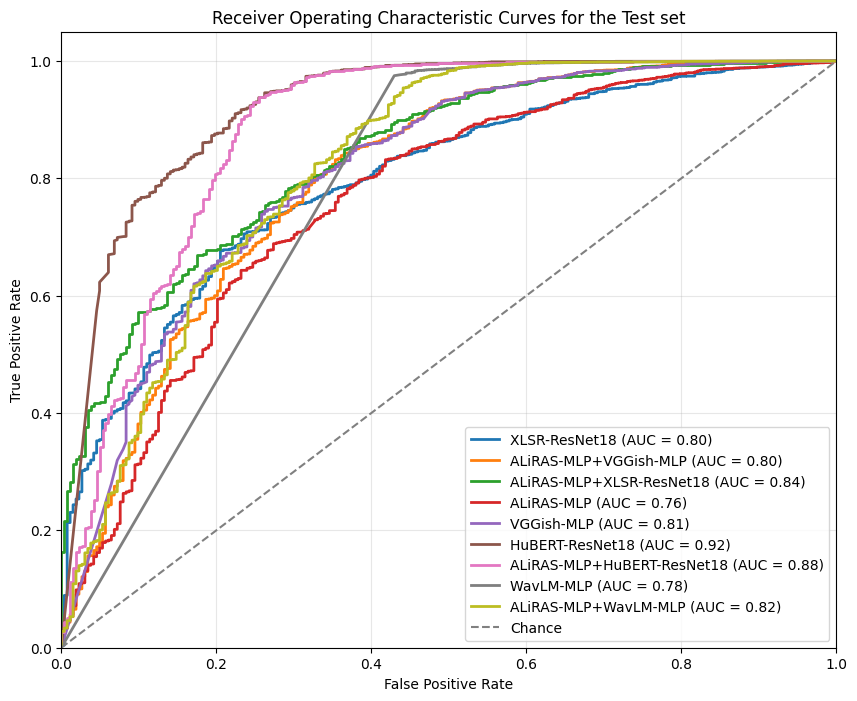

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True labels
y_true = df_test_final['Label']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof_from_XLSR_ResNet18'],
    'ALiRAS-MLP+VGGish-MLP': df_test_final['prob_spoof_from_aliras_vggish'],
    'ALiRAS-MLP+XLSR-ResNet18': df_test_final['prob_spoof_from_aliras_xlsr'],
    'ALiRAS-MLP': df_test_final['prob_spoof_from_aliras_mlp'],
    'VGGish-MLP': df_test_final['prob_spoof_from_vggish_mlp'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert_resnet18'],
    'ALiRAS-MLP+HuBERT-ResNet18': df_test_final['prob_spoof_from_aliras_hubert'],
    'WavLM-MLP': df_test_final['prob_spoof_wavlm_mlp'],
    'ALiRAS-MLP+WavLM-MLP': df_test_final['prob_spoof_from_aliras_wavlm']
}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
cost_efficient_wavlm_aliras_test = df_test_final.apply(
    lambda row: 1 if row['prob_spoof_from_aliras_mlp'] > 0.54 else row['prob_spoof_wavlm_mlp'],
    axis=1
)


In [ ]:
cost_efficient_hubert_aliras_test = df_test_final.apply(
    lambda row: 1 if row['prob_spoof_from_aliras_mlp'] > 0.54 else row['prob_spoof_hubert_resnet18'],
    axis=1
)

In [ ]:
df_test_final

,FileName,prob_spoof_wavlm_mlp,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_hubert,prob_spoof_from_aliras_wavlm,prob_spoof_from_aliras_wavlm_cost_efficient
0,DF_E_2000011,1.0,1.000000,0.931213,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.509246,0.506505,0.002466,0.904300,0.562474,0.521502,1.000000,0.856451,0.856451,1.0
1,DF_E_2000013,1.0,0.999395,0.958799,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.391012,0.181437,0.003677,0.901393,0.565281,0.521556,0.996353,0.856044,0.856467,1.0
2,DF_E_2000024,1.0,1.000000,0.003900,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.775842,0.784149,0.000334,0.910243,0.496486,0.551218,0.999999,0.865365,0.865365,1.0
3,DF_E_2000026,1.0,1.000000,0.535835,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.905625,0.511231,0.000951,0.910214,0.549548,0.551072,1.000000,0.865322,0.865322,1.0
4,DF_E_2000027,1.0,1.000000,0.007246,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.655513,0.618699,0.579733,0.903117,0.470805,0.522311,0.998319,0.856693,0.856693,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,DF_E_2034401,1.0,0.999865,0.805376,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.664837,0.474970,0.143835,0.904294,0.549968,0.521589,0.999970,0.856382,0.856477,1.0
6996,DF_E_2034402,1.0,1.000000,0.620533,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.924276,0.436578,0.003243,0.910336,0.558567,0.551682,1.000000,0.865505,0.865505,1.0
6997,DF_E_2034405,1.0,0.998028,0.999959,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.516034,0.553612,0.847947,0.899790,0.549050,0.498949,1.000000,0.848304,0.849685,1.0
6998,DF_E_2034408,1.0,0.999553,0.040554,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.480987,0.316607,0.844016,0.894681,0.436970,0.481016,0.998097,0.843992,0.844305,1.0


In [ ]:
cost_efficient_xlsr_aliras_test = df_test_final.apply(
    lambda row: 1 if row['prob_spoof_from_aliras_mlp'] > 0.54 else row['prob_spoof_from_XLSR_ResNet18'],
    axis=1
)


In [ ]:
cost_efficient_wavlm_aliras_train = df_train_final.apply(
    lambda row: 1 if row['prob_spoof_from_aliras_mlp'] > 0.54 else row['prob_spoof_wavlm_mlp'],
    axis=1
)


In [ ]:
#cost_efficient_xlsr_aliras_test = df_test_final['cost_efficient_xlsr_aliras']

In [ ]:
roc_auc = roc_auc_score(y_train, cost_efficient_wavlm_aliras_train)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9964676719454632


In [ ]:


roc_auc = roc_auc_score(y_test, cost_efficient_wavlm_aliras_test)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.7686192648169835


In [ ]:
cost_efficient_wavlm_aliras_train

,0
0,1.000000e+00
1,1.755506e-08
2,1.000000e+00
3,1.000000e+00
4,1.000000e+00
...,...
6994,1.000000e+00
6995,1.000000e+00
6996,1.000000e+00
6997,1.000000e+00


In [ ]:
compute_eer(y_train, cost_efficient_wavlm_aliras_train)

(np.float64(0.005111710504797534), np.float64(1.0))

In [ ]:
compute_eer_fixed_threshold(y_test, cost_efficient_wavlm_aliras_test, 0.644977305802142)

np.float64(0.2847843247082791)

In [ ]:
df_test_final['prob_spoof_from_aliras_wavlm_cost_efficient'] = cost_efficient_wavlm_aliras_test

In [ ]:
df_train_final['prob_spoof_from_aliras_wavlm_cost_efficient'] = cost_efficient_wavlm_aliras_train

In [ ]:
df_test_final['prob_spoof_from_aliras_xlsr_cost_efficient'] = cost_efficient_xlsr_aliras_test

In [ ]:
df_test_final['cost_efficient_hubert_aliras'] = cost_efficient_hubert_aliras_test

In [ ]:
df_test_final

,FileName,prob_spoof_wavlm_mlp,prob_spoof_hubert_resnet18,prob_spoof_from_XLSR_ResNet18,Path,Label,audio_quality,pitch,breath,prob_spoof_from_aliras_vggish,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_mlp,prob_spoof_from_vggish_mlp,prob_spoof_from_aliras_hubert,prob_spoof_from_aliras_wavlm,prob_spoof_from_aliras_wavlm_cost_efficient,prob_spoof_from_aliras_xlsr_cost_efficient,cost_efficient_hubert_aliras
0,DF_E_2000011,1.0,1.000000,0.931213,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.509246,0.506505,0.002466,0.904300,0.562474,0.521502,1.000000,0.856451,0.856451,1.0,0.931213,1.000000
1,DF_E_2000013,1.0,0.999395,0.958799,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.391012,0.181437,0.003677,0.901393,0.565281,0.521556,0.996353,0.856044,0.856467,1.0,0.958799,0.999395
2,DF_E_2000024,1.0,1.000000,0.003900,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.775842,0.784149,0.000334,0.910243,0.496486,0.551218,0.999999,0.865365,0.865365,1.0,1.000000,1.000000
3,DF_E_2000026,1.0,1.000000,0.535835,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.905625,0.511231,0.000951,0.910214,0.549548,0.551072,1.000000,0.865322,0.865322,1.0,1.000000,1.000000
4,DF_E_2000027,1.0,1.000000,0.007246,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.655513,0.618699,0.579733,0.903117,0.470805,0.522311,0.998319,0.856693,0.856693,1.0,0.007246,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,DF_E_2034401,1.0,0.999865,0.805376,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.664837,0.474970,0.143835,0.904294,0.549968,0.521589,0.999970,0.856382,0.856477,1.0,0.805376,0.999865
6996,DF_E_2034402,1.0,1.000000,0.620533,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.924276,0.436578,0.003243,0.910336,0.558567,0.551682,1.000000,0.865505,0.865505,1.0,1.000000,1.000000
6997,DF_E_2034405,1.0,0.998028,0.999959,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.516034,0.553612,0.847947,0.899790,0.549050,0.498949,1.000000,0.848304,0.849685,1.0,0.999959,0.998028
6998,DF_E_2034408,1.0,0.999553,0.040554,/nfs/rs/vjaneja/users/zkhanja1/ASVspoof2021_DF...,1.0,0.480987,0.316607,0.844016,0.894681,0.436970,0.481016,0.998097,0.843992,0.844305,1.0,0.040554,0.999553


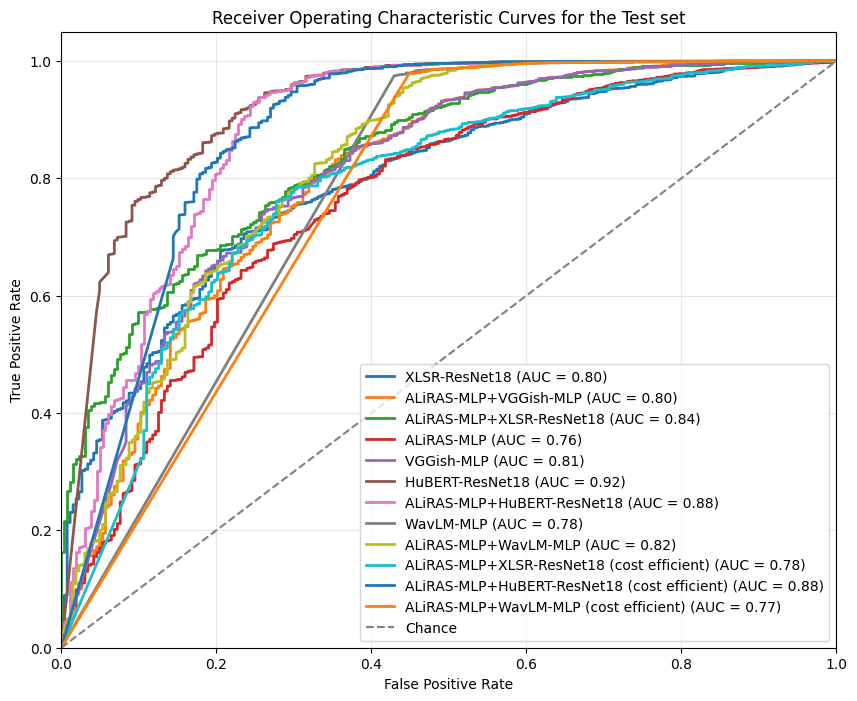

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True labels
y_true = df_test_final['Label']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof_from_XLSR_ResNet18'],
    'ALiRAS-MLP+VGGish-MLP': df_test_final['prob_spoof_from_aliras_vggish'],
    'ALiRAS-MLP+XLSR-ResNet18': df_test_final['prob_spoof_from_aliras_xlsr'],
    'ALiRAS-MLP': df_test_final['prob_spoof_from_aliras_mlp'],
    'VGGish-MLP': df_test_final['prob_spoof_from_vggish_mlp'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert_resnet18'],
    'ALiRAS-MLP+HuBERT-ResNet18': df_test_final['prob_spoof_from_aliras_hubert'],
    'WavLM-MLP': df_test_final['prob_spoof_wavlm_mlp'],
    'ALiRAS-MLP+WavLM-MLP': df_test_final['prob_spoof_from_aliras_wavlm'],
    'ALiRAS-MLP+XLSR-ResNet18 (cost efficient)': df_test_final['prob_spoof_from_aliras_xlsr_cost_efficient'],
    'ALiRAS-MLP+HuBERT-ResNet18 (cost efficient)': df_test_final['cost_efficient_hubert_aliras'],
    'ALiRAS-MLP+WavLM-MLP (cost efficient)': df_test_final['prob_spoof_from_aliras_wavlm_cost_efficient']

}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# how much cost efficient is really efficient?
count = (df_test_final['prob_spoof_from_aliras_mlp'] <= 0.54).sum()
print(f'Number of rows with prob_spoof_from_aliras_mlp which will be hubert for them < 0.54: {count}')


Number of rows with prob_spoof_from_aliras_mlp which will be hubert for them < 0.54: 4815


6998-4815= 2183 number of saved samples from xlsr gpu cost. In the way if aliras y_pred is more than 0.54 , then the final y_pred is 1, otherwise, we will extract the xlsr.  31% Cost/Time reduction !

In [ ]:
df_test_final.to_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/wavlm_predictions/cost_efficient_DF_test_probs_aliras_vggish_xlsr_hubert_wavlm_ensemble_7000version_matched.csv', index=False)

In [ ]:
#df_train_final.to_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/round2(all_matched_orders)/hubert_predictions/cost_efficient_DF_train_probs_aliras_vggish_xlsr_hubert_ensemble_7000version_matched.csv', index=False)